<h4>The 3rd component model - Sentiment Analysis Model</h4>

In [91]:
# !pip install nltk
# !pip install textblob
# !pip install -U SpaCy
# !python -m spacy download en_core_web_lg
# !pip install backtrader
# !pip install scikeras
# !pip install --upgrade xgboost
# !pip install tensorflow-text
# !pip install bbc-feeds

In [92]:
# Import NLP libraries.
from textblob import TextBlob
import spacy
import nltk
import warnings
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
import csv
import pandas as pd
import en_core_web_lg
nlp = en_core_web_lg.load()

# Libraries for processing the news headlines.
from lxml import etree
import json
from io import StringIO
from os import listdir
from os.path import isfile, join
from pandas.tseries.offsets import BDay
from scipy.stats.mstats import winsorize
from copy import copy

# Libraries for Classification for modeling the sentiments.
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV

# Keras package for the deep learning model for the sentiment prediction.
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Flatten, LSTM, Dropout, Activation
from keras.layers import Embedding
from scikeras.wrappers import KerasClassifier
from tensorflow import keras

# Import for trade simulation
import backtrader as bt
import backtrader.indicators as btind
import backtrader.analyzers as btanalyzers

# Import other general use libraries
import statsmodels.api as sm
import seaborn as sns
import pandas as pd
from pandas import option_context
import numpy as np
import datetime
from datetime import date, datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib import pyplot
import yfinance as yf
import bbc_feeds
import json
import zipfile
import os.path
import sys
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [93]:
# The data period used to train and test the component models is 2025/1/1 to 2025/12/31.
# The data period used to train and test the combined model is 2023/12/1 to 2024/11/30.
# However, as the sentiment analysis model does't need the financial data to train (will be using another set of labled data from Kaggle instead).
# below get the data period for the combined model, which will also be used for using which method to use as shown in later sections.
endDate = date(2024, 11, 30)
startDate = date(2023, 12, 1)

# For the sentiment analysis model, it is trying to learn the information hidden in news. As the impact of news will likely to reflect on market index, so choose S&P500.
stk_tickers = ['^GSPC']

In [94]:
# Getting the finance data
financeData = yf.download(stk_tickers, start = startDate, end = endDate, interval = '1d')
financeData.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
financeData = financeData.reset_index()
# financeData

[*********************100%***********************]  1 of 1 completed


In [95]:
# Getting the news data
# data source: https://www.kaggle.com/datasets/gpreda/bbc-news
newsData = pd.read_csv('bbc_news.csv')
newsData = newsData.drop(columns=['guid', 'link', 'description'])
newsData.columns = ['prevHeadline', 'Date']
newsData['Date'] = pd.to_datetime(newsData['Date']).dt.date
newsData['Date'] = newsData['Date'] + timedelta(days = 1) # Since the impact of the news are likely to be delay, shifted one day to match with the return.
newsData = newsData.dropna()
newsData_grouped = newsData.groupby('Date')['prevHeadline'].apply(', '.join)
# newsData_grouped

In [96]:
# After both the finance and news dataset are ready, compute the return for the finance dataset
# financeData['return'] = financeData['Open'].pct_change().shift(-1)
financeData['return'] = financeData['Open'].pct_change()
financeData['Date'] = pd.to_datetime(financeData['Date']).dt.date
# financeData

In [97]:
# Then the finance dataset and the news dataset are combined for the sentiment analysis
sentData = pd.merge(newsData_grouped, financeData, how = 'left', left_on = ['Date'], right_on = ['Date'])
sentData = sentData[['prevHeadline', 'Date', 'return', 'Open']]
sentData = sentData.dropna()
# sentData

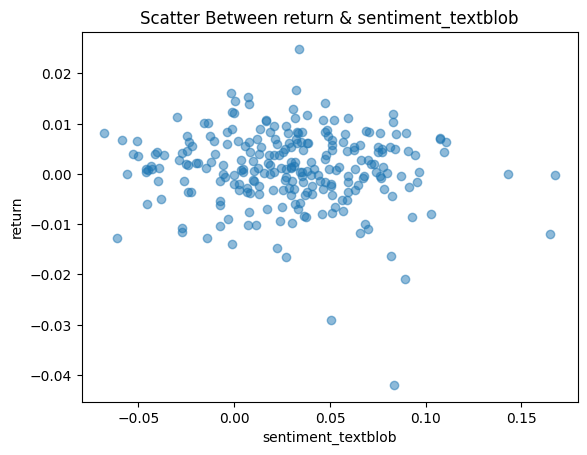

Correlation_sentiment_textblob: -0.07886142382866543


In [98]:
# To start with, the first method of sentiment analysis is from textblob is used
# https://medium.com/@qudrohbidemi/sentiment-analysis-project-using-textblob-216d3fe119fc
newsData['sentiment_textblob'] = [TextBlob(s).sentiment.polarity for s in newsData['prevHeadline']]
temp_df = newsData[['Date','sentiment_textblob']]
temp_df = temp_df.groupby(['Date'])['sentiment_textblob'].mean()
sentData = pd.merge(sentData, temp_df, how = 'left', left_on = ['Date'], right_on = ['Date'])

# Then check on the correlation between return and sentiment
plt.scatter(sentData['sentiment_textblob'], sentData['return'], alpha = 0.5)
plt.title('Scatter Between return & sentiment_textblob')
plt.ylabel('return')
plt.xlabel('sentiment_textblob')
plt.show()
print('Correlation_sentiment_textblob: ' + str(sentData['return'].corr(sentData['sentiment_textblob'])))

In [99]:
# After the pre-trained textblob model, the second method of sentiment analysis is to build a customised model with supervised learning
# data source: https://www.kaggle.com/datasets/yash612/stockmarket-sentiment-dataset
training_sentData = pd.read_csv(r'stock_data.csv')
training_sentData.columns = ['prevHeadline', 'sentiment']
training_sentData['sentiment'] = np.where(training_sentData['sentiment'] >= 0, 1, -1)
training_sentData = training_sentData.dropna()
# training_sentData

In [100]:
# settings
validation_size = 0.3
seed = 7

# getting data ready for training and testing
Y = training_sentData['sentiment']
X = np.array([np.array([token.vector for token in nlp(s)]).mean(axis = 0) * np.ones((300)) for s in training_sentData['prevHeadline']]) # word-embedding
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = validation_size, random_state = seed)

In [101]:
# settings for the classification model training
num_folds = 10
seed = 7
scoring = 'accuracy'

# list of algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('SVM', SVC()))
models.append(('NN', MLPClassifier())) # Neural Network
models.append(('RF', RandomForestClassifier())) # Ensemble learning

In [102]:
# loop through each model to train and test
modelNames = []
test_results = []
train_results = []
for name, model in models:
  # cross-validation
  kfold = KFold(n_splits = num_folds, random_state = seed, shuffle = True)
  cv_results = cross_val_score(model, X_train, Y_train, cv = kfold, scoring = scoring)
  modelNames.append(name)

  # Training
  res = model.fit(X_train, Y_train)
  train_result = accuracy_score(res.predict(X_train), Y_train)
  train_results.append(train_result)

  # Testing
  test_result = accuracy_score(res.predict(X_test), Y_test)
  test_results.append(test_result)

  # showing results
  print(name + ':')
  print('avg_cross_val_score-%f std-%f' % (cv_results.mean(), cv_results.std()))
  print('train_result-%f test_result-%f' % (train_result, test_result))
  print('confusion_matrix')
  print(confusion_matrix(res.predict(X_test), Y_test))
  print('classification_report')
  print(classification_report(res.predict(X_test), Y_test))

LR:
avg_cross_val_score-0.723172 std-0.022003
train_result-0.757710 test_result-0.746260
confusion_matrix
[[324 144]
 [297 973]]
classification_report
              precision    recall  f1-score   support

          -1       0.52      0.69      0.60       468
           1       0.87      0.77      0.82      1270

    accuracy                           0.75      1738
   macro avg       0.70      0.73      0.71      1738
weighted avg       0.78      0.75      0.76      1738

KNN:
avg_cross_val_score-0.672095 std-0.021462
train_result-0.782137 test_result-0.651323
confusion_matrix
[[264 249]
 [357 868]]
classification_report
              precision    recall  f1-score   support

          -1       0.43      0.51      0.47       513
           1       0.78      0.71      0.74      1225

    accuracy                           0.65      1738
   macro avg       0.60      0.61      0.60      1738
weighted avg       0.67      0.65      0.66      1738

CART:
avg_cross_val_score-0.584753 std-0.01

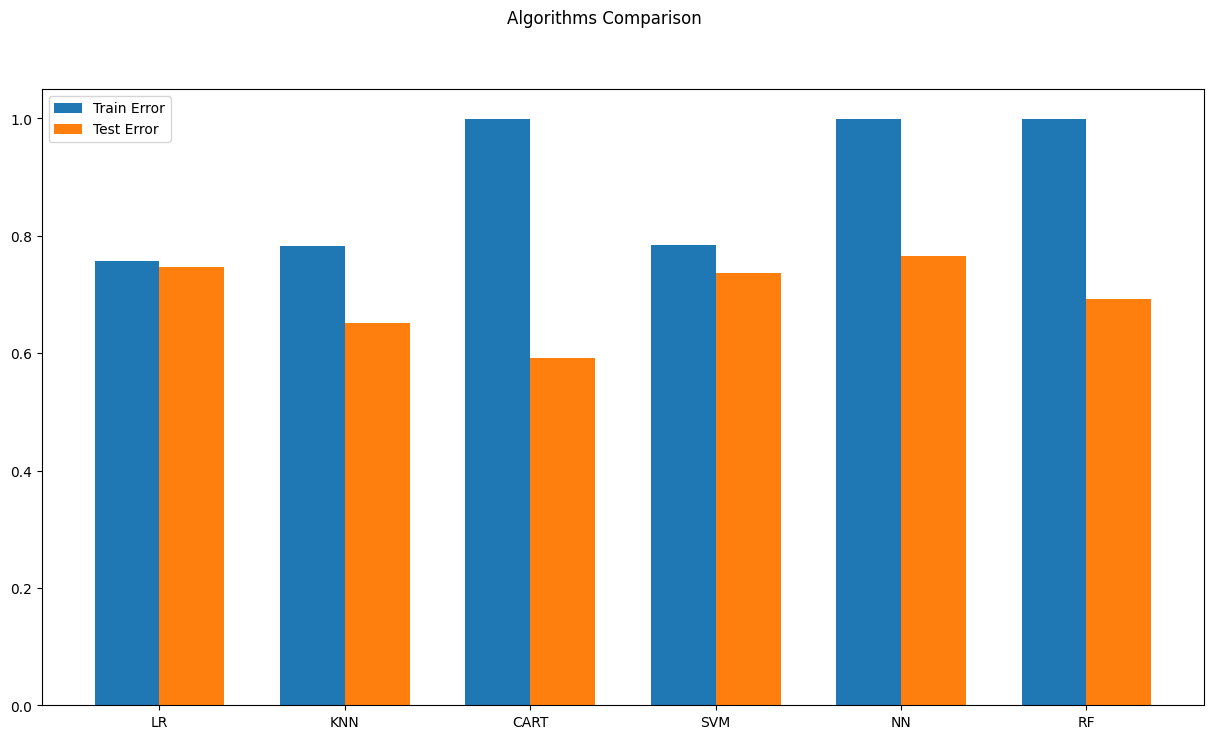

In [103]:
# Compare algorithms
fig = pyplot.figure()
ind = np.arange(len(modelNames))
width = 0.35
fig.suptitle('Algorithms Comparison')
ax = fig.add_subplot(111)
pyplot.bar(ind - width / 2, train_results,  width = width, label = 'Train Error')
pyplot.bar(ind + width / 2, test_results, width = width, label = 'Test Error')
fig.set_size_inches(15, 8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(modelNames)
pyplot.show()

In [104]:
# for natural language processing, RNN models are preferred. So below also try the LSTM model.

# Create sequence
vocabulary_size = 40000
tokenizer = Tokenizer(num_words = vocabulary_size)
tokenizer.fit_on_texts(training_sentData['prevHeadline'])
sequences = tokenizer.texts_to_sequences(training_sentData['prevHeadline'])
X_whole_LSTM = pad_sequences(sequences, maxlen = 100)

In [105]:
# getting data ready for training and testing
Y_whole_LSTM = training_sentData["sentiment"]
X_train_LSTM, X_test_LSTM, Y_train_LSTM, Y_test_LSTM = train_test_split(X_whole_LSTM, Y_whole_LSTM, test_size = validation_size, random_state = seed)

In [106]:
# create and train the LSTM model
def create_model(input_length = 100):
  model = Sequential()
  model.add(Embedding(20000, 200, input_length = 100, input_shape = (X_train_LSTM.shape[1],)))
  model.add(LSTM(40, dropout = 0.3, recurrent_dropout = 0.3))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
  return model
model_LSTM = KerasClassifier(build_fn = create_model, epochs = 6, verbose = 1, validation_split = 0.3)
model_LSTM.fit(X_train_LSTM, Y_train_LSTM)
train_result_LSTM = accuracy_score(model_LSTM.predict(X_train_LSTM), Y_train_LSTM)

# Testing
test_result_LSTM = accuracy_score(model_LSTM.predict(X_test_LSTM), Y_test_LSTM)

Epoch 1/6
89/89 ━━━━━━━━━━━━━━━━━━━━ 21s 184ms/step - accuracy: 0.6436 - loss: 0.6346 - val_accuracy: 0.7146 - val_loss: 0.5766
Epoch 2/6
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - accuracy: 0.8111 - loss: 0.4320 - val_accuracy: 0.7697 - val_loss: 0.5168
Epoch 3/6
89/89 ━━━━━━━━━━━━━━━━━━━━ 21s 156ms/step - accuracy: 0.9274 - loss: 0.2112 - val_accuracy: 0.7673 - val_loss: 0.5618
Epoch 4/6
89/89 ━━━━━━━━━━━━━━━━━━━━ 21s 157ms/step - accuracy: 0.9662 - loss: 0.1010 - val_accuracy: 0.7599 - val_loss: 0.6495
Epoch 5/6
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 157ms/step - accuracy: 0.9841 - loss: 0.0537 - val_accuracy: 0.7664 - val_loss: 0.8392
Epoch 6/6
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.9926 - loss: 0.0295 - val_accuracy: 0.7541 - val_loss: 0.9321
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step


In [107]:
# showing results
print('LSTM:')
print('train_result_LSTM-%f test_result_LSTM-%f' % (train_result_LSTM, test_result_LSTM))
print('confusion_matrix_LSTM')
print(confusion_matrix(model_LSTM.predict(X_test_LSTM), Y_test_LSTM))
print('classification_report_LSTM')
print(classification_report(model_LSTM.predict(X_test_LSTM), Y_test_LSTM))

LSTM:
train_result_LSTM-0.925241 test_result_LSTM-0.769275
confusion_matrix_LSTM
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
[[394 174]
 [227 943]]
classification_report_LSTM
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
              precision    recall  f1-score   support

          -1       0.63      0.69      0.66       568
           1       0.84      0.81      0.82      1170

    accuracy                           0.77      1738
   macro avg       0.74      0.75      0.74      1738
weighted avg       0.78      0.77      0.77      1738



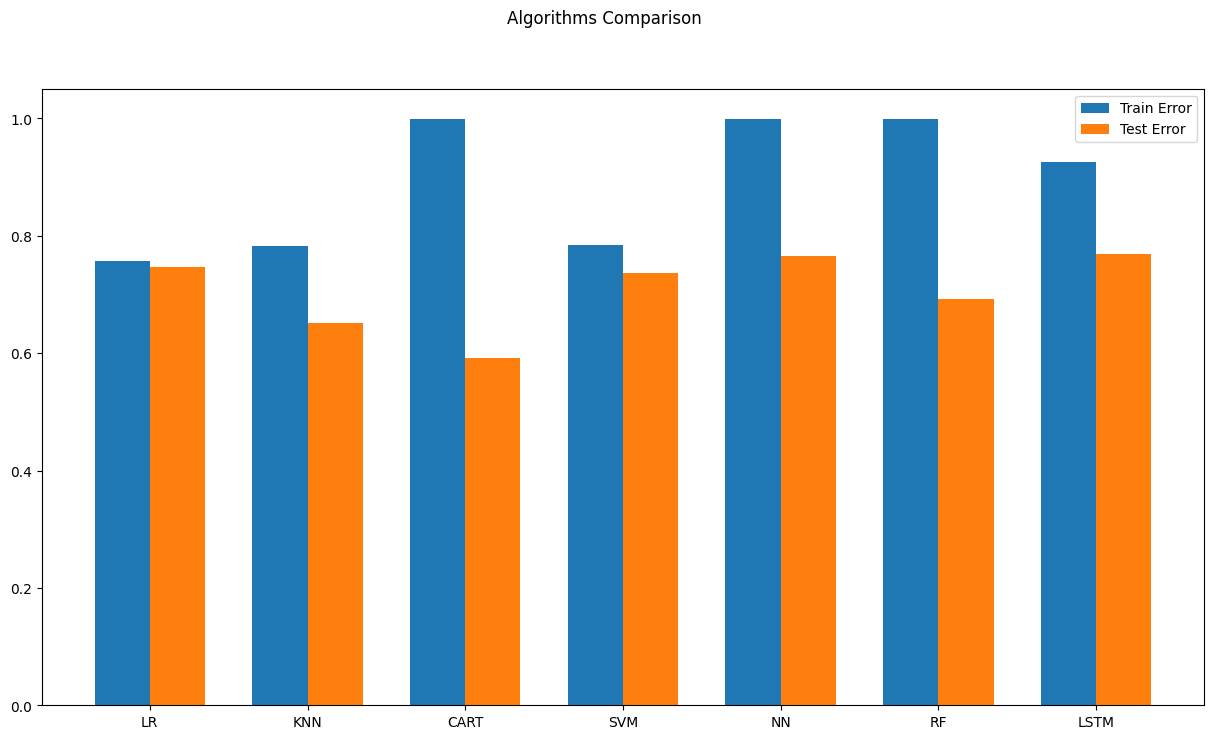

In [108]:
# compare algorithms
train_results.append(train_result_LSTM)
test_results.append(test_result_LSTM)
modelNames.append("LSTM")
fig = pyplot.figure()
ind = np.arange(len(modelNames))
width = 0.35
fig.suptitle('Algorithms Comparison')
ax = fig.add_subplot(111)
pyplot.bar(ind - width / 2, train_results,  width = width, label = 'Train Error')
pyplot.bar(ind + width / 2, test_results, width = width, label = 'Test Error')
fig.set_size_inches(15, 8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(modelNames)
pyplot.show()

1317/1317 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step


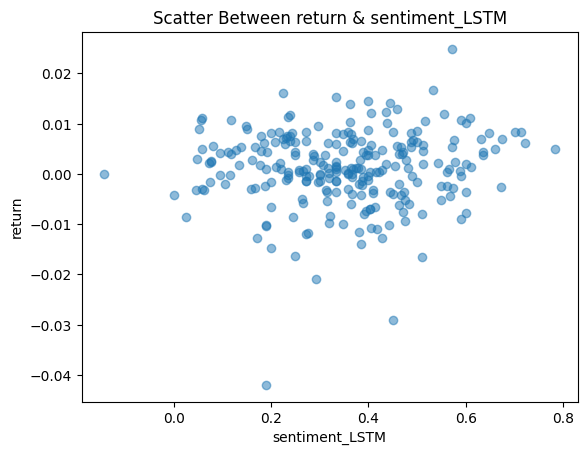

Correlation_sentiment_LSTM: 0.0675275060116223


In [109]:
# after trying various different settings, LSTM performed the best.
# so apply on the original news data
sequences_LSTM = tokenizer.texts_to_sequences(newsData['prevHeadline'])
X_LSTM = pad_sequences(sequences_LSTM, maxlen = 100)
Y_LSTM = model_LSTM.predict(X_LSTM)
newsData['sentiment_LSTM'] = Y_LSTM
temp_df = newsData[['Date','sentiment_LSTM']]
temp_df = temp_df.groupby(['Date'])['sentiment_LSTM'].mean()
sentData = pd.merge(sentData, temp_df, how = 'left', left_on = ['Date'], right_on = ['Date'])

# Then check on the correlation between return and sentiment
plt.scatter(sentData['sentiment_LSTM'], sentData['return'], alpha = 0.5)
plt.title('Scatter Between return & sentiment_LSTM')
plt.ylabel('return')
plt.xlabel('sentiment_LSTM')
plt.show()
print('Correlation_sentiment_LSTM: ' + str(sentData['return'].corr(sentData['sentiment_LSTM'])))

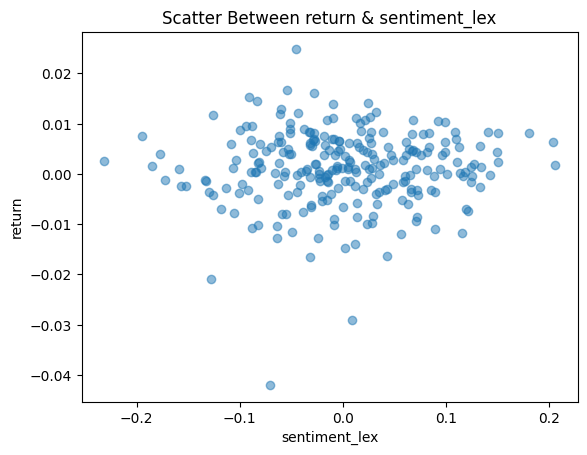

Correlation_sentiment_lex: 0.03359337323434308


In [110]:
# lastly, the third method of sentiment analysis is the lexicon method
sia = SentimentIntensityAnalyzer()
# data source: https://github.com/tatsath/fin-ml/blob/master/Chapter%2010%20-%20Natural%20Language%20Processing/Case%20Study%201%20-%20NLP%20and%20Sentiments%20Analysis%20based%20Trading%20Strategy/Data/LexiconData.csv
lexData = pd.read_csv('LexiconData.csv')
lexData['sentiment'] = (lexData['Aff_Score'] + lexData['Neg_Score'])/2
lexData = dict(zip(lexData.Item, lexData.sentiment))
lexData = {k:v for k,v in lexData.items() if len(k.split(' '))==1}
lexData_scaled = {}
for k, v in lexData.items():
  if v > 0:
    lexData_scaled[k] = v / max(lexData.values()) * 4
  else:
    lexData_scaled[k] = v / min(lexData.values()) * -4

lexData_final = {}
lexData_final.update(lexData_scaled)
lexData_final.update(sia.lexicon)
sia.lexicon = lexData_final

newsData['sentiment_lex'] = np.array([sia.polarity_scores(s)['compound'] for s in newsData['prevHeadline']])
temp_df = newsData[['Date','sentiment_lex']]
temp_df = temp_df.groupby(['Date'])['sentiment_lex'].mean()
sentData = pd.merge(sentData, temp_df, how = 'left', left_on = ['Date'], right_on = ['Date'])

# Then check on the correlation between return and sentiment
plt.scatter(sentData['sentiment_lex'], sentData['return'], alpha = 0.5)
plt.title('Scatter Between return & sentiment_lex')
plt.ylabel('return')
plt.xlabel('sentiment_lex')
plt.show()
print('Correlation_sentiment_lex: ' + str(sentData['return'].corr(sentData['sentiment_lex'])))

<Axes: title={'center': 'Correlation Comparison'}>

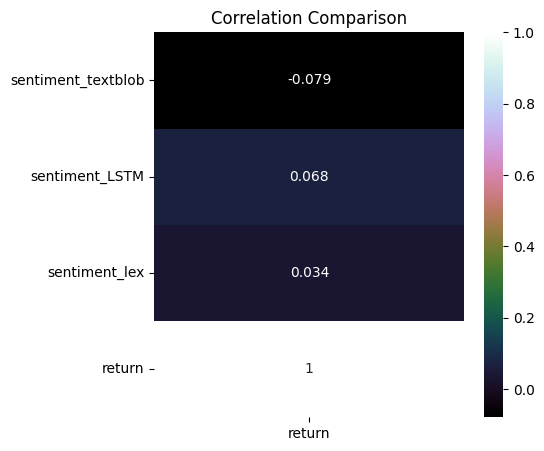

In [111]:
# Finally, all three methods are compared in order to choose which method to use.
cor_comparison = sentData[['sentiment_textblob', 'sentiment_LSTM', 'sentiment_lex', 'return']].dropna(axis = 0).corr()
plt.figure(figsize=(5, 5))
plt.title('Correlation Comparison')
sns.heatmap(cor_comparison[['return']], vmax = 1, annot = True, cmap = 'cubehelix')

In [117]:
# after choosing supervised machine learning method with LSTM, use backtrader package to simulate the trading process

# setting up the backtrader simulation
class Indicate(bt.Indicator):
  lines = ('indicate',)
  plotinfo = dict(plotymargin = 0.5, plothlines = [0], plotyticks = [1.0, 0, -1.0])

  def next(self):
    self.indicate = 0.0
    self.date = self.data.datetime
    date = bt.num2date(self.date[0]).date()
    if date in date_indicate:
      self.indicate = date_indicate[date]
    self.lines.indicate[0] = self.indicate


class IndicateStrategy(bt.Strategy):
  params = (('period', 15), ('printlog', True),)

  def log(self, txt, dt=None, doprint=False):
    if self.params.printlog or doprint:
      dt = dt or self.datas[0].datetime.date(0)
      if showTradingDetails:
        print('%s, %s' % (dt.isoformat(), txt))

  def __init__(self):
    self.dataclose = self.datas[0].close
    self.order = None
    self.buyprice = None
    self.buycomm = None
    self.date = self.data.datetime
    self.indicate = None
    Indicate(self.data)
    self.plotinfo.plot = False

  def notify_order(self, order):
    if order.status in [order.Submitted, order.Accepted]:
      return
    if order.status in [order.Completed]:
      if order.isbuy(): # Buy
        if showTradingDetails:
          self.log('Buy @ %.2f' % (order.executed.price))
        self.buyprice = order.executed.price
        self.buycomm = order.executed.comm
      else:  # Sell
        if showTradingDetails:
          self.log('Sell @ %.2f' % (order.executed.price))
      self.bar_executed = len(self)
    elif order.status in [order.Canceled, order.Margin, order.Rejected]:
      if showTradingDetails:
        self.log('Order Canceled/Margin/Rejected')
    self.order = None

  def notify_trade(self, trade):
    if not trade.isclosed:
      return
    if showTradingDetails:
      self.log('^ Profit %.2f' % (trade.pnl))

  # Strategy
  def next(self):
    date = bt.num2date(self.date[0]).date()
    if date in date_indicate:
      self.indicate = date_indicate[date]
    # Check if any pending order
    if self.order:
      return
    # Check if Buy already
    if not self.position: # not in buy position
      if self.indicate >= buyTrigger:
        self.order = self.buy()
    elif self.position: # in buy position
      if self.indicate < buyTrigger:
        self.order = self.sell()

def run_strategy(ticker, start, end):
  ticker = yf.Ticker(ticker)
  df_ticker = ticker.history(start = start, end = end)
  cerebro = bt.Cerebro(cheat_on_open=True) # buy at open
  cerebro.addstrategy(IndicateStrategy)
  data = bt.feeds.PandasData(dataname = df_ticker)
  cerebro.adddata(data)
  startMoney = 100
  cerebro.broker.setcash(startMoney)
  cerebro.addsizer(bt.sizers.PercentSizer, percents = 98)
  if showTradingDetails:
    print('Starting Value: ' + str(startMoney))
  cerebro.run()
  endMoney = cerebro.broker.getvalue()
  if showTradingDetails:
    print('Ending Portfolio Value: %.2f\nProfit: %.2f\n' % (endMoney, (endMoney - startMoney)))
  return (endMoney - startMoney)

In [118]:
# chosing the indicator and get data ready for simulation
date_indicate = sentData
date_indicate = date_indicate[['Date','sentiment_LSTM']]
date_indicate = date_indicate.sort_values(by = 'Date', ascending = True)
date_indicate = date_indicate.set_index('Date')['sentiment_LSTM']
date_indicate = date_indicate.to_dict()

In [119]:
# in the simulation, if the indicator is higher/lower than some trigger value, perform buy/sell
# below check which trigger value to use, by trying out differnet n-th percentile
bestSettings = [0, 0] # profit, buyTrigger
showTradingDetails = False
for i in range(1, 100):
  buyTrigger = np.percentile(sentData['sentiment_LSTM'], i)
  profit = run_strategy(stk_tickers[0], start = sentData['Date'].min(), end = sentData['Date'].max())
  if profit > bestSettings[0]:
    bestSettings = [profit, buyTrigger]

# run the sumulation with the best trigger values found
showTradingDetails = True
buyTrigger = bestSettings[1]
profit = run_strategy(stk_tickers[0], start = sentData['Date'].min(), end = sentData['Date'].max())

Starting Value: 100
2023-12-05, Buy @ 4557.25
2023-12-06, Sell @ 4586.23
2023-12-06, ^ Profit 0.62
2023-12-07, Buy @ 4568.84
2023-12-28, Sell @ 4786.44
2023-12-28, ^ Profit 4.72
2023-12-29, Buy @ 4782.88
2024-02-20, Sell @ 4989.32
2024-02-20, ^ Profit 4.46
2024-02-21, Buy @ 4963.03
2024-03-04, Sell @ 5130.99
2024-03-04, ^ Profit 3.63
2024-03-05, Buy @ 5110.52
2024-04-01, Sell @ 5257.97
2024-04-01, ^ Profit 3.19
2024-04-02, Buy @ 5204.29
2024-04-16, Sell @ 5064.59
2024-04-16, ^ Profit -3.04
2024-04-17, Buy @ 5068.97
2024-04-25, Sell @ 5019.88
2024-04-25, ^ Profit -1.08
2024-04-26, Buy @ 5084.65
2024-05-17, Sell @ 5303.10
2024-05-17, ^ Profit 4.77
2024-05-20, Buy @ 5305.35
2024-06-27, Sell @ 5473.59
2024-06-27, ^ Profit 3.65
2024-06-28, Buy @ 5488.48
2024-07-02, Sell @ 5461.84
2024-07-02, ^ Profit -0.58
2024-07-03, Buy @ 5507.44
2024-07-19, Sell @ 5543.37
2024-07-19, ^ Profit 0.77
2024-07-22, Buy @ 5544.54
2024-08-07, Sell @ 5293.13
2024-08-07, ^ Profit -5.42
2024-08-08, Buy @ 5252.57
20

In [123]:
# After showing the model is valid, save it for later use
model_LSTM.model_.save("SA_model.keras")
# also save the sentiment estimated for later to use when training and testing the combined model
sentData = sentData[['Date','sentiment_LSTM']]
sentData.to_csv('sentiment_Data.csv')

In [124]:
# below shows how to perform sentiment analysis on latest news

# get latest news
news_stories = bbc_feeds.news().all()
titles = []
for story in news_stories:
  titles.append(story['title'])

# load the LSTM model previously saved
model_LSTM_loaded = keras.models.load_model('model_LSTM_created.keras')
sequences_LSTM = tokenizer.texts_to_sequences(titles)
X_LSTM = pad_sequences(sequences_LSTM, maxlen = 100)
Y_LSTM = model_LSTM_loaded.predict(X_LSTM)
indicatorValue = Y_LSTM.mean()
print('Sentiment on latest news: %.2f' % (indicatorValue))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 412ms/step
Sentiment on latest news: 0.66
